# 逻辑回归模型用于预测考试通过率和学习时间/睡眠时间的关系

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.lines import Line2D
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

"""配置中文字体，避免图表中文字乱码。"""
rcParams["font.family"] = ["SimHei", "Microsoft YaHei"]
plt.rcParams["axes.unicode_minus"] = False

In [ ]:
RANDOM_SEED = 42
OUTPUT_IMAGE = "logistic_regression_decision_boundary.png"
OUTPUT_DATA = "data1.csv"

In [6]:
data = np.genfromtxt(OUTPUT_DATA, delimiter=",", names=True)
# 特征 X：学习小时数和睡眠小时数。
features = np.column_stack((data["study_hours"], data["sleep_hours"]))

# 标签 y：是否通过考试。1 表示通过，0 表示未通过。
labels = data["passed"].astype(int)

In [ ]:
def train_model(features, labels):
    """使用 scikit-learn 的 LogisticRegression 训练逻辑回归模型。"""
    # 把数据集拆成训练集和测试集
    x_train, x_test, y_train, y_test = train_test_split(
        features,
        labels,
        test_size=0.25,
        random_state=RANDOM_SEED,
        stratify=labels,
    )

    model = LogisticRegression()
    # 用于训练逻辑回归模型的方法
    model.fit(x_train, y_train)

    # 用训练好的模型对测试集进行预测，输出的是类别结果
    y_pred = model.predict(x_test)
    # 用训练好的模型对测试集预测概率
    y_probability = model.predict_proba(x_test)[:, 1]

    return model, x_train, x_test, y_train, y_test, y_pred, y_probability
    """输出模型训练后的关键结果。"""
    accuracy = accuracy_score(y_test, y_pred)
    matrix = confusion_matrix(y_test, y_pred)

    print("逻辑回归模型训练完成")
    print("-" * 40)
    print(f"准确率 accuracy: {accuracy:.4f}")
    print()

    print("模型学到的参数：")
    print(f"bias/intercept = {model.intercept_[0]:.4f}")
    print(f"study_hours 权重 = {model.coef_[0][0]:.4f}")
    print(f"sleep_hours 权重 = {model.coef_[0][1]:.4f}")
    print()

    print("混淆矩阵：")
    print(matrix)
    print()

    print("分类报告：")
    print(classification_report(y_test, y_pred, target_names=["未通过", "通过"]))

    print("前 10 个测试样本的通过概率：")
    for index, probability in enumerate(y_probability[:10], start=1):
        print(f"样本 {index:>2}: 通过概率 = {probability:.4f}")

def print_result(model, y_test, y_pred, y_probability):
    """输出模型训练后的关键结果。"""
    accuracy = accuracy_score(y_test, y_pred)
    matrix = confusion_matrix(y_test, y_pred)

    print("逻辑回归模型训练完成")
    print("-" * 40)
    print(f"准确率 accuracy: {accuracy:.4f}")
    print()

    print("模型学到的参数：")
    print(f"bias/intercept = {model.intercept_[0]:.4f}")
    print(f"study_hours 权重 = {model.coef_[0][0]:.4f}")
    print(f"sleep_hours 权重 = {model.coef_[0][1]:.4f}")
    print()

    print("混淆矩阵：")
    print(matrix)
    print()

    print("分类报告：")
    print(classification_report(y_test, y_pred, target_names=["未通过", "通过"]))

    print("前 10 个测试样本的通过概率：")
    for index, probability in enumerate(y_probability[:10], start=1):
        print(f"样本 {index:>2}: 通过概率 = {probability:.4f}")

def plot_decision_boundary(model, features, labels):
    """绘制逻辑回归的决策边界。"""
    x_min, x_max = features[:, 0].min() - 0.5, features[:, 0].max() + 0.5
    y_min, y_max = features[:, 1].min() - 0.5, features[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 250),
        np.linspace(y_min, y_max, 250),
    )

    grid = np.column_stack((xx.ravel(), yy.ravel()))
    probabilities = model.predict_proba(grid)[:, 1].reshape(xx.shape)

    plt.figure(figsize=(10, 7))

    # 背景颜色表示模型预测“通过”的概率。
    contour = plt.contourf(
        xx,
        yy,
        probabilities,
        levels=20,
        cmap="RdYlGn",
        alpha=0.55,
    )
    plt.colorbar(contour, label="预测通过概率")

    # 概率为 0.5 的位置就是逻辑回归的决策边界。
    plt.contour(
        xx,
        yy,
        probabilities,
        levels=[0.5],
        colors="black",
        linewidths=2,
    )

    plt.scatter(
        features[labels == 0, 0],
        features[labels == 0, 1],
        color="#dc2626",
        edgecolor="white",
        s=55,
        label="未通过",
    )
    plt.scatter(
        features[labels == 1, 0],
        features[labels == 1, 1],
        color="#16a34a",
        edgecolor="white",
        s=55,
        label="通过",
    )

    plt.title("逻辑回归案例：学习和睡眠对考试通过概率的影响")
    plt.xlabel("每天学习小时数")
    plt.ylabel("每天睡眠小时数")
    boundary_label = Line2D([0], [0], color="black", linewidth=2, label="决策边界 P=0.5")
    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(handles + [boundary_label], labels + ["决策边界 P=0.5"])
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_IMAGE, dpi=160, bbox_inches="tight")
    print(f"\n决策边界图已保存到: {OUTPUT_IMAGE}")
    plt.show()

总数据量: 300
训练集数量: 225
测试集数量: 75

逻辑回归模型训练完成
----------------------------------------
准确率 accuracy: 0.8667

模型学到的参数：
bias/intercept = -6.3779
study_hours 权重 = 1.0765
sleep_hours 权重 = 0.4547

混淆矩阵：
[[17  7]
 [ 3 48]]

分类报告：
              precision    recall  f1-score   support

         未通过       0.85      0.71      0.77        24
          通过       0.87      0.94      0.91        51

    accuracy                           0.87        75
   macro avg       0.86      0.82      0.84        75
weighted avg       0.87      0.87      0.86        75

前 10 个测试样本的通过概率：
样本  1: 通过概率 = 0.9237
样本  2: 通过概率 = 0.9930
样本  3: 通过概率 = 0.0800
样本  4: 通过概率 = 0.9060
样本  5: 通过概率 = 0.9981
样本  6: 通过概率 = 0.9976
样本  7: 通过概率 = 0.9455
样本  8: 通过概率 = 0.7066
样本  9: 通过概率 = 0.7004
样本 10: 通过概率 = 0.8210

决策边界图已保存到: logistic_regression_decision_boundary.png


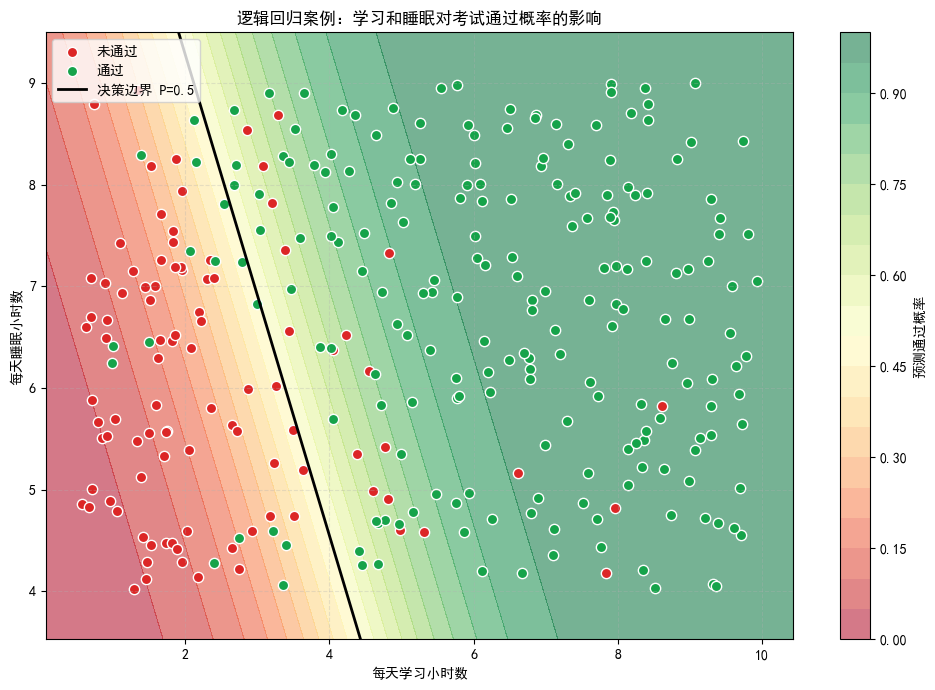

In [12]:
model, x_train, x_test, y_train, y_test, y_pred, y_probability = train_model(features,labels,)

print(f"总数据量: {len(features)}")
print(f"训练集数量: {len(x_train)}")
print(f"测试集数量: {len(x_test)}")
print()

print_result(model, y_test, y_pred, y_probability)
plot_decision_boundary(model, features, labels)